# Simulazione d'esame Laboratorio di Programmazione 2

## Esercizio 1

1. Crea un vettore NumPy con i seguenti **canoni mensili d'affitto** (in euro) per 4 appartamenti: **720, 980, 650, 1200**

2. Calcola la **spesa totale mensile** sostenuta dagli inquilini.

3. Il proprietario dell'appartamento da **1200 €** decide di **aumentare l’affitto del 12%**.
    - Modifica il vettore per applicare l’aumento.
    - L’importo aggiornato deve essere esattamente **1344,00 €**, controlla se appare **esattamente** nel tuo array.


4. L'inquilino dell'appartamento da **650 €** ottiene uno **sconto del 10%**.
    - Applica la modifica.

5. Gli altri due appartamenti (**720 € e 980 €**) subiscono un **aumento del 5%**.
    - Aggiorna il vettore di conseguenza.

7. Calcola la **nuova spesa totale mensile** dopo tutti i cambiamenti.

8. Infine: quanto ha influito **l’aumento dell’affitto più alto** sulla spesa complessiva?

    (Suggerimento: confronta la spesa totale **prima di qualsiasi modifica** e **dopo il solo aumento del canone a 1200 €**.)


In [1]:
import numpy as np

In [14]:
a = np.array([720, 980, 650, 1200])

spesa_tot = np.sum(a)
print(f"spesa totale prima delle modifiche : {spesa_tot}")

a[a == 1200] = a[a == 1200] * 1.12
spesa_post_aumento = np.sum(a)

a[a == 650] = a[a == 650] * 0.90
a[a == 720] = a[a == 720] * 1.05
a[a == 980] = a[a == 980] * 1.05

spesa_tot2 = np.sum(a)
print(f"spesa totale dopo le modifiche : {spesa_tot2}")

influenza = spesa_post_aumento - spesa_tot
print(f"l'aumento dell'affitto più alto ha portato {influenza} soldi in più")


spesa totale prima delle modifiche : 3550
spesa totale dopo le modifiche : 3714
l'aumento dell'affitto più alto ha portato 144 soldi in più


## Esercizio 2

Consideriamo un semplice processo di random walk (cammino aleatorio) in una dimensione:
a ogni passo temporale, un camminatore si sposta a destra (+1) o a sinistra (-1) con uguale probabilità. Supponiamo che il camminatore parta sempre da x=0.

1. Scrivi una funzione che simula il cammino per n passi ed N camminatori e restituisce due array. Il primo rappresenta la media della posizione ad ogni passo degli N camminatori ed il secondo la deviazione standard della posizione ad ogni passo degli N camminatori.

2. Fai prima il plot della media delle posizione degli N camminatori per 100 passi 

3. Fai il plot con anche la devizione standard.  La deviazione standard diminuisce all'aumentare del campione? Che andamento ha la deviazione standard rispeto l tempo/passi?

In [15]:
import matplotlib.pyplot as plt

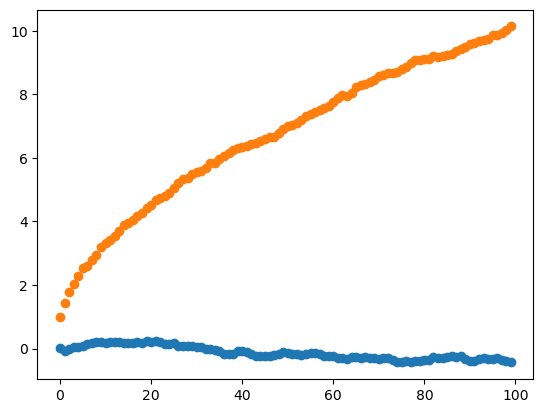

In [ ]:
# numero camminatori (colonne della matrice)
N = 500
# numero passi (righe della matrice)
n = 100

# Genera 0 e 1, poi li trasforma in -1 e +1
matrice_passi = 2 * np.random.randint(0, 2, size=(n, N)) - 1

# print(matrice_passi)


def funzione(matrice, N, n):
    # Calcoliamo la matrice delle posizioni (somma cumulata lungo le righe)
    posizioni = np.cumsum(matrice, axis=0)
    

    media_passi = np.mean(posizioni, axis=1)
    
    std_passi = np.std(posizioni, axis=1)
    # saranno vettori lunchi n

    return media_passi, std_passi

media, std = funzione(matrice_passi, N, n)

# print(f"media cumulativa della posizione dopo tot passi : {media}")
# print(f"deviazione standard cumulativa della posizione dopo tot passi : {std}")

x = np.arange(n)

plt.scatter(x, media)
plt.scatter(x, std)

# noto che la deviazione standard aumenta con il crescere dei passi e l'andamento sembra quello di una radice quadrata

## Esercizio 3

Genera un array `a` di dimensioni **5 x 9** contenente numeri da una distribuzione gaussiana con media 0 e dev standard 1.  
Per ogni riga, seleziona il numero **più vicino a 0.1**.
Imposta il seed per la riproducibilità `np.random.seed(42)`

 *Suggerimento*: per ottenere `a[i, j]`, l'array `i` deve contenere gli **indici di riga** corrispondenti agli elementi in `j`.


In [62]:
np.random.seed(42)

a = np.random.normal(0.0, 1.0, size = (5, 9))

distanze = np.abs(a - 0.1)

indici_colonne = np.argmin(distanze, axis=1)

indici_righe = np.arange(5)
numeri_vicini = a[indici_righe, indici_colonne]


print(a)
print(f"i numeri per ogni riga più vicini a 1 sono : {numeri_vicini}")

[[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
   1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783
  -0.56228753 -1.01283112  0.31424733]
 [-0.90802408 -1.4123037   1.46564877 -0.2257763   0.0675282  -1.42474819
  -0.54438272  0.11092259 -1.15099358]
 [ 0.37569802 -0.60063869 -0.29169375 -0.60170661  1.85227818 -0.01349722
  -1.05771093  0.82254491 -1.22084365]
 [ 0.2088636  -1.95967012 -1.32818605  0.19686124  0.73846658  0.17136828
  -0.11564828 -0.3011037  -1.47852199]]
i numeri per ogni riga più vicini a 1 sono : [-0.1382643   0.24196227  0.11092259 -0.01349722  0.17136828]


## Esercizio 4

Utilizza il dataset `titanic`, disponibile all'url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

Esegui un’analisi esplorativa sui dati dei passeggeri, focalizzandoti su tariffe, età e componenti familiari.

1. **Visualizza i primi 10 passeggeri ordinati per tariffa pagata** (`Fare`), dal più alto al più basso.

2. **Calcola la media** di:
   - `Age` (età)
   - `Fare` (tariffa)
   - `SibSp` (numero di fratelli/coniugi a bordo)

3. **Crea una nuova colonna** chiamata `Family_index`, definita come:

   $$
   \texttt{family\_index} = \frac{\texttt{sibsp} + \texttt{parch}}{\texttt{fare}}
   $$

   *(Indicatore del “peso familiare” per unità di spesa – attenzione a eventuali divisioni per zero!)*

4. Trova il **passeggero con il valore massimo** di `Family_index`.

5. **Filtra solo i passeggeri** che hanno pagato **più di 100** di tariffa (`Fare > 100`).

6. **Crea un grafico a barre** con i 10 passeggeri che hanno pagato di più (`Fare`).

7. **Crea un grafico a linee** dell’età (`Age`), ordinando i passeggeri per tariffa (`Fare`) crescente.



💡 *Suggerimenti*:
- Ricordati di gestire eventuali valori mancanti in `Age` o `Fare` prima di fare operazioni.


In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.sort_values(by ="Fare", ascending = False).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S


In [10]:
media_age = df["Age"].mean()
media_tariffa = df["Fare"].mean()
media_passeggeri = df["SibSp"].mean()

print(f" media delle età : {media_age} \n media delle tariffe : {media_tariffa} \n media di fratelli o cugini a bordo : {media_passeggeri}")

 media delle età : 29.69911764705882 
 media delle tariffe : 32.204207968574636 
 media di fratelli o cugini a bordo : 0.5230078563411896


In [ ]:
df["Family_index"] = ( df["SibSp"] + df["Parch"] ) / df["Fare"]

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_index
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.137931
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.014029
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.000000
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.018832
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.000000


In [40]:
df_tmp = df.sort_values(by = "Family_index", ascending = False).reset_index()
print(f"l'individuo con il maggior family index è {df_tmp["Name"][0]}")
print(f"con un family index di : {df_tmp["Family_index"][0]}")

l'individuo con il maggior family index è Andersson, Miss. Erna Alexandra
con un family index di : 0.7570977917981073


In [ ]:
df[df["Fare"] > 100]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_index
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.137931
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.014029
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.000000
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.018832
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0.000000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0.000000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0.127932
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0.000000


Text(0.5, 0, 'Fare = tariffa')

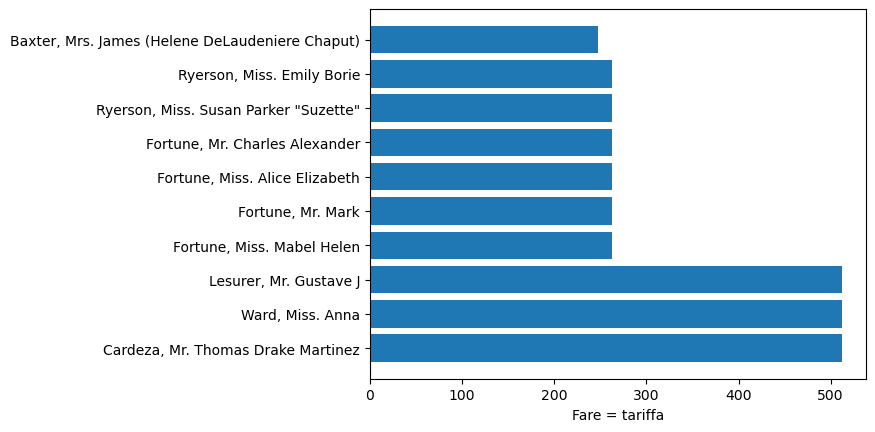

In [73]:
import matplotlib.pyplot as plt

df_plot = df.sort_values(by = "Fare", ascending = False).reset_index()
valori = df_plot["Fare"][0:10]
nomi = df_plot["Name"][0:10]

plt.barh(nomi, valori)
plt.xlabel("Fare = tariffa")

<Axes: xlabel='Fare'>

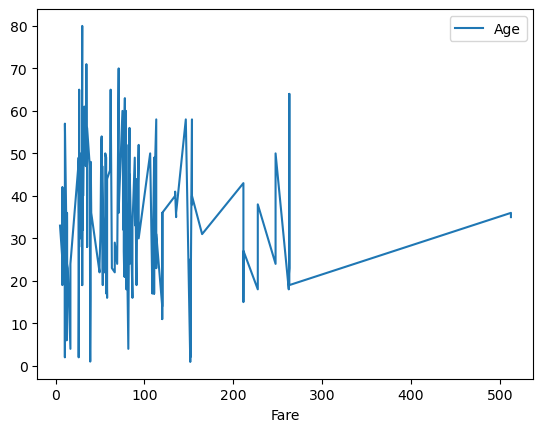

In [82]:
df_pulito = df.dropna()
df_linee = df_pulito.sort_values(by = "Fare")

df_linee.plot('Fare', 'Age', kind = 'line')

## Esercizio 5

Usa il dataset `penguins`, disponibile tramite `seaborn.load_dataset("penguins")`.


1. Quante righe e colonne ha il dataset?

2. Controlla quanti valori mancanti ci sono per colonna.

3. Riempi i valori mancanti nella colonna `sex` con il valore più frequente.

4. Rimuovi le righe in cui il valore `body_mass_g` è mancante.

5. Controlla se ci sono righe duplicate.

6. Calcola la **massa corporea media** (`body_mass_g`) per ogni specie (`species`).
  Se ci sono valori mancanti in `body_mass_g`, riempili con la media della specie.

7. Visualizza la **distribuzione della massa corporea** (`body_mass_g`) per specie.

8.  Visualizza la **distribuzione della massa corporea** per specie, **dividendo per sesso** (`sex`) e mostrandoli a confronto.


💡 Suggerimento: usa `seaborn.violinplot()`, `boxplot()` o `kdeplot()` con `hue='sex'`.


In [100]:
import seaborn as sns

df = sns.load_dataset("penguins")
print(f"numero righe : {df.shape[0]}")
print(f"numero colonne : {df.shape[1]}")

n_na = df.shape[0] - df.count()
print(f" \nnumero di NA per colonna : \n{n_na}")


numero righe : 344
numero colonne : 7
 
numero di NA per colonna : 
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [111]:
frequente = df["sex"].mode()[0]
df["sex"] = df["sex"].fillna(frequente)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,Male
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,Male
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [114]:
df.dropna(subset = "body_mass_g", inplace = True)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [115]:
df.drop_duplicates()
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
df.groupby('species')['body_mass_g'].mean()

species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64

<Axes: xlabel='species', ylabel='body_mass_g'>

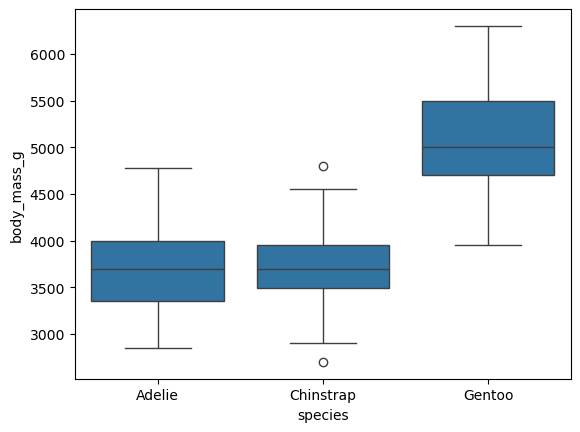

In [117]:
sns.boxplot(df, x = 'species', y = 'body_mass_g')

<Axes: xlabel='species', ylabel='body_mass_g'>

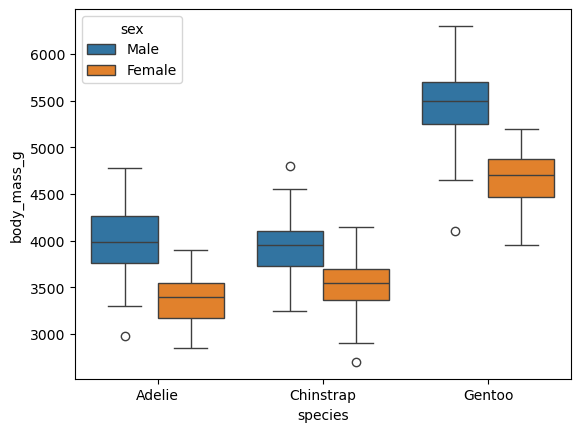

In [118]:
sns.boxplot(df, x = 'species', y = 'body_mass_g', hue = 'sex')

## Esercizio 6

Hai due array NumPy generati come segue:

`x = np.linspace(0, 10, 100)`  
`y = 3 * x + 2 + np.random.normal(0, 1, 100)`

Scrivi una funzione `fit_line(x, y)` che:

- usa `scipy.optimize.curve_fit` per eseguire un **fitting lineare** del tipo `y = a * x + b`;  
- restituisce una tupla contenente:
  - i **parametri ottimizzati** `a` e `b`;  
  - una **stringa** che descrive la retta trovata, ad esempio: `"y = 3.02 * x + 1.95"`.


Esempio di output atteso:   (3.02, 1.95, "y = 3.02 * x + 1.95")

Fai un esempio di utilizzo dove poi plotti i dati e la curva ottenuta.


(np.float64(2.99), np.float64(2.11), 'y = 2.99 * x + 2.11')


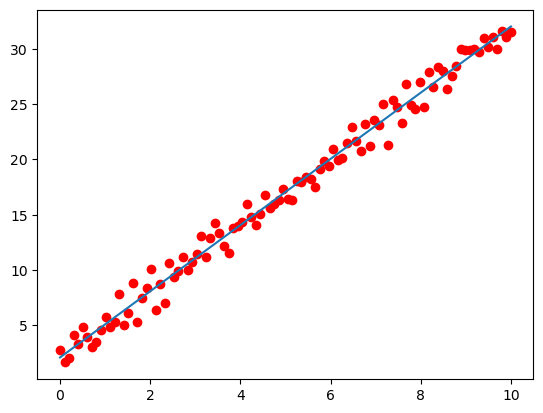

In [142]:
import numpy as np
import scipy as sp

x = np.linspace(0, 10, 100)
y = 3*x + 2 + np.random.normal(0, 1, 100)

def retta (x, m, q):
    return m*x + q

def fit_line(x, y):
    stime, _ = sp.optimize.curve_fit(retta, x, y)
    m_pred = stime[0].round(2)
    q_pred = stime[1].round(2)
    return (m_pred, q_pred, f"y = {m_pred} * x + {q_pred}")

tupla_soluzioni = fit_line(x, y)
print (f"{tupla_soluzioni}")

plt.scatter(x, y, color = "red")
plt.plot(x, retta(x, fit_line(x, y)[0], fit_line(x, y)[1]))
